# 03 — Embeddings + Clustering — Black Basta

Genera embeddings de mensajes con `qwen3-embedding` (4096 dims).  
Con solo 49 actores podemos añadir una sección extra:  
**comparativa directa con los perfiles de Conti** (si están disponibles).

Produce:
- `data/processed/bb_message_embeddings.npy` — matriz (N, 4096)
- `data/processed/bb_actor_embeddings.parquet` — centroide por actor + cluster + rol
- `data/processed/bb_sample_with_embeddings.parquet` — muestra + cluster por mensaje

## 0. Setup

In [2]:
# sys y Path: herramientas estándar para manejar rutas y módulos en Python.
import sys
from pathlib import Path

# Añadimos la carpeta 'src' a la búsqueda de módulos de Python.
sys.path.insert(0, str(Path('src').resolve()))

# json: para leer el fichero de perfiles de actores (guardado en formato JSON).
import json

# numpy es la librería fundamental para cálculo numérico en Python.
# Trabaja con "arrays" (matrices de números) de forma muy eficiente.
# La convención es importarla como 'np'.
import numpy as np

# pandas para cargar y manipular el DataFrame de mensajes clasificados.
import pandas as pd

# ollama para comunicarse con el modelo de embeddings local.
import ollama

# umap es un algoritmo de reducción de dimensionalidad: convierte vectores
# de miles de dimensiones en 2 dimensiones para poder visualizarlos en un gráfico.
# Es similar a PCA pero mejor para detectar estructuras no lineales.
import umap

# hdbscan es un algoritmo de clustering (agrupamiento) jerárquico basado en densidad.
# Detecta grupos de puntos que están "cerca" entre sí sin necesidad de especificar
# cuántos grupos queremos. También puede marcar puntos como "ruido" si no pertenecen
# claramente a ningún grupo.
import hdbscan

# matplotlib para crear gráficos.
import matplotlib.pyplot as plt

# matplotlib.cm contiene paletas de colores predefinidas para los gráficos.
import matplotlib.cm as cm

# cosine_similarity calcula qué tan "parecidos" son dos vectores.
# La similitud coseno devuelve 1 si son idénticos y 0 si son completamente distintos.
# La usamos para medir qué tan similares son los patrones de comunicación entre actores.
from sklearn.metrics.pairwise import cosine_similarity

# tqdm para mostrar barras de progreso en los bucles largos.
from tqdm.auto import tqdm

# Definimos las rutas de todos los ficheros de entrada y salida.
PROCESSED_DIR = Path('../data_Vruto/BlackBasta')

# Fichero de entrada: mensajes ya clasificados por el notebook 02.
SAMPLE_IN      = PROCESSED_DIR / 'bb_sample_classified.parquet'

# Fichero de entrada: perfiles JSON de actores generados por el notebook 02.
PROFILES_IN    = PROCESSED_DIR / 'bb_actor_profiles.json'

# Fichero de salida: matriz de embeddings guardada como fichero binario numpy (.npy).
# Si ya existe, lo cargamos directamente para no volver a generarlo (proceso lento).
EMBEDDINGS_NPY = PROCESSED_DIR / 'bb_message_embeddings.npy'

# Fichero de salida: tabla con el centroide, cluster y rol de cada actor.
ACTOR_EMB_OUT  = PROCESSED_DIR / 'bb_actor_embeddings.parquet'

# Fichero de salida: muestra completa con coordenadas UMAP y cluster por mensaje.
SAMPLE_OUT     = PROCESSED_DIR / 'bb_sample_with_embeddings.parquet'

# Nombre del modelo de embeddings que usaremos (corriendo localmente en Ollama).
# Un "embedding" es una representación numérica de un texto: convierte palabras
# y frases en vectores de números que capturan su significado semántico.
# qwen3-embedding genera vectores de 4096 dimensiones por cada texto.
EMBED_MODEL = 'qwen3-embedding'

# Número de dimensiones que genera el modelo de embeddings.
EMBED_DIMS  = 4096

# Cuántos textos enviamos al modelo en cada llamada.
# Un batch más grande es más eficiente pero requiere más memoria.
BATCH_SIZE  = 32

# Verificamos que los ficheros de entrada existen antes de continuar.
for p in [SAMPLE_IN, PROFILES_IN]:
    assert p.exists(), f'No se encuentra {p} — ejecuta primero el notebook 02'
print('Setup OK')

Setup OK


## 1. Cargar datos

In [3]:
# Cargamos la muestra de mensajes clasificados generada en el notebook 02.
# read_parquet() es mucho más rápido que leer un CSV equivalente.
sample = pd.read_parquet(SAMPLE_IN)

# Cargamos los perfiles de actores desde el fichero JSON.
# open con 'r' (por defecto) abre el fichero para lectura.
# json.load() convierte el contenido JSON en un diccionario Python.
with open(PROFILES_IN, encoding='utf-8') as f:
    profiles = json.load(f)

# Mostramos un resumen para verificar que los datos se cargaron correctamente.
print(f'Mensajes : {len(sample):,}')
print(f'Actores  : {sample.username.nunique()}')
print(f'\nCategorías:\n{sample.category.value_counts().to_string()}')

Mensajes : 3,598
Actores  : 47

Categorías:
category
technical         1054
comms             1051
unknown            777
operational        543
financial          122
organizational      51


## 2. Generar embeddings

In [4]:
# Comprobamos si los embeddings ya se calcularon y guardaron en una ejecución anterior.
# Generar embeddings es el paso más lento (tarda varios minutos), así que si ya
# los tenemos en disco los cargamos directamente para no repetir el trabajo.
if EMBEDDINGS_NPY.exists():
    # np.load() carga un array de numpy desde un fichero .npy.
    # .npy es un formato binario eficiente específico de numpy.
    embeddings = np.load(EMBEDDINGS_NPY)

    # Verificamos que el número de embeddings coincide con el número de mensajes.
    # Si no coinciden, algo fue mal en la generación anterior.
    assert len(embeddings) == len(sample)
    print(f'Embeddings cargados desde caché: {embeddings.shape}')
else:
    # Si no hay fichero en disco, generamos los embeddings desde cero.

    # Extraemos el texto de cada mensaje como una lista simple de cadenas.
    # .tolist() convierte la Series de pandas a una lista de Python.
    texts = sample['message'].str.strip().tolist()

    # Creamos una matriz vacía de ceros donde iremos almacenando los embeddings.
    # np.zeros((N, D)) crea una matriz de N filas y D columnas rellena con ceros.
    # dtype=np.float32 usa números de 32 bits (precisión simple) en lugar de 64,
    # lo que reduce a la mitad el espacio en memoria sin perder calidad para este uso.
    embeddings = np.zeros((len(texts), EMBED_DIMS), dtype=np.float32)

    # Procesamos los mensajes en lotes (batches) de BATCH_SIZE textos a la vez.
    # range(0, len(texts), BATCH_SIZE) genera los índices de inicio de cada lote:
    # 0, 32, 64, 96, ... hasta llegar al final.
    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc='Generando embeddings'):
        # Seleccionamos el lote actual: de 'start' a 'start + BATCH_SIZE'.
        batch = texts[start:start + BATCH_SIZE]

        # Enviamos el lote al modelo de embeddings y recibimos los vectores.
        # ollama.embed() devuelve un objeto con la lista de vectores en .embeddings.
        resp  = ollama.embed(model=EMBED_MODEL, input=batch)

        # Guardamos cada embedding en la fila correspondiente de la matriz.
        # enumerate(resp.embeddings) nos da (j=0, emb=vector_0), (j=1, emb=vector_1), ...
        for j, emb in enumerate(resp.embeddings):
            embeddings[start + j] = emb

    # Guardamos los embeddings en disco para no tener que generarlos de nuevo.
    # np.save() guarda el array en formato binario .npy, muy eficiente.
    np.save(EMBEDDINGS_NPY, embeddings)
    print(f'Guardado → {EMBEDDINGS_NPY}  {embeddings.shape}')

Embeddings cargados desde caché: (3598, 4096)


## 3. Centroides por actor

In [5]:
# Añadimos una columna con el índice de posición de cada mensaje en la matriz de embeddings.
# Esto nos permite luego recuperar el embedding de cada mensaje por su posición.
# range(len(sample_emb)) genera los números 0, 1, 2, ..., N-1.
sample_emb = sample.copy()
sample_emb['emb_idx'] = range(len(sample_emb))

# Calculamos el "centroide" de cada actor: el vector promedio de todos sus mensajes.
# El centroide representa el "punto central" del actor en el espacio de embeddings,
# es decir, una especie de "firma" que resume el estilo y temática de sus mensajes.
actor_centroids = {}

# Iteramos sobre cada actor y el grupo de sus mensajes.
# groupby('username') agrupa las filas del DataFrame por usuario.
for actor, group in sample_emb.groupby('username'):
    # Obtenemos las posiciones (índices) de los embeddings de este actor.
    idxs = group['emb_idx'].tolist()

    # embeddings[idxs] selecciona las filas de la matriz de embeddings correspondientes.
    # .mean(axis=0) calcula la media elemento a elemento entre todos los vectores del actor,
    # produciendo un único vector promedio (el centroide).
    actor_centroids[actor] = embeddings[idxs].mean(axis=0)

# Construimos una matriz donde cada fila es el centroide de un actor.
# list(actor_centroids.values()) convierte los valores del diccionario a una lista.
# np.array() convierte esa lista de vectores en una matriz 2D de numpy.
actor_matrix = np.array(list(actor_centroids.values()))

# Guardamos los nombres de los actores en el mismo orden que las filas de actor_matrix.
# Esto es crucial para poder identificar después a qué actor pertenece cada punto del gráfico.
actor_names  = list(actor_centroids.keys())
print(f'Centroides: {actor_matrix.shape}')

Centroides: (47, 4096)


## 4. UMAP + HDBSCAN

In [6]:
# Creamos el objeto UMAP con los parámetros de reducción de dimensionalidad.
# UMAP (Uniform Manifold Approximation and Projection) convierte vectores de 4096
# dimensiones en vectores de 2 dimensiones manteniendo la estructura de proximidad:
# mensajes o actores "parecidos" quedan cerca en el gráfico 2D.
reducer = umap.UMAP(
    # n_components=2: queremos reducir a 2 dimensiones para visualizar en un plano.
    n_components=2,
    # n_neighbors=10: cuántos vecinos cercanos considera para aprender la geometría.
    # Con 49 actores usamos 10 (menos que con 485 actores de Conti donde se usaría más).
    n_neighbors=10,
    # min_dist=0.1: distancia mínima entre puntos en el espacio reducido.
    # Valores más bajos generan clusters más compactos.
    min_dist=0.1,
    # metric='cosine': usamos similitud coseno para medir distancias entre vectores.
    # Es la métrica más adecuada para embeddings de texto.
    metric='cosine',
    # random_state=42: fija la semilla aleatoria para que el resultado sea reproducible.
    # Sin esto, UMAP daría un resultado distinto cada vez que se ejecuta.
    random_state=42
)

print('Ajustando UMAP...')

# fit_transform() aprende la proyección a partir de los embeddings de todos los mensajes
# y al mismo tiempo proyecta esos mismos mensajes a 2D.
# El resultado es una matriz de forma (N_mensajes, 2).
msg_2d   = reducer.fit_transform(embeddings)

# transform() proyecta los centroides de los actores al mismo espacio 2D que ya aprendió.
# NO re-entrena UMAP; usa la proyección ya calculada con fit_transform().
# El resultado es una matriz de forma (N_actores, 2).
actor_2d = reducer.transform(actor_matrix)

# HDBSCAN agrupa los actores según su proximidad en el espacio 2D de UMAP.
# Esto nos permite descubrir grupos de actores con roles o estilos de comunicación similares.
# min_cluster_size=3: un grupo necesita al menos 3 actores para ser considerado cluster.
# min_samples=2: controla cuán conservador es el algoritmo al asignar puntos a clusters.
# metric='euclidean': distancia euclídea en el espacio 2D para medir cercanía.
clusterer = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=2, metric='euclidean')

# fit_predict() entrena el clusterer y devuelve el número de cluster de cada actor.
# -1 significa que ese actor no pertenece a ningún cluster (es "ruido").
actor_clusters = clusterer.fit_predict(actor_2d)

# Contamos cuántos clusters distintos se encontraron, excluyendo el -1 (ruido).
n_clusters = len(set(actor_clusters)) - (1 if -1 in actor_clusters else 0)
n_noise    = (actor_clusters == -1).sum()
print(f'Clusters: {n_clusters}  |  Ruido: {n_noise} actores')

# Mostramos qué actores quedaron en cada cluster para interpretarlos manualmente.
for cl in sorted(set(actor_clusters)):
    members = [actor_names[i] for i, c in enumerate(actor_clusters) if c == cl]
    label   = 'ruido' if cl == -1 else f'cluster {cl}'
    print(f'  {label:<12}: {members}')

Ajustando UMAP...


/home/drjekyll/FearOfTheDark/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clusters: 3  |  Ruido: 4 actores
  ruido       : ['arslanshabbirmalik', 'username777', 'usernameboy', 'usernamehh']
  cluster 0   : ['adm', 'burito', 'cameron777', 'chuck', 'iamnurnazarov', 'lincoln', 'manager361', 'manager880', 'mel', 'n3auxaxl', 'ng', 'princehorn', 'ssd', 'ugw', 'usernameff', 'usernamegg', 'usernamenn', 'usernamevv']
  cluster 1   : ['blood', 'cob_crypt_ward', 'colin', 'lapa', 'nickolas', 'staffer', 'sunortla', 'timber', 'tinker', 'u123', 'usernamehunter', 'usernamenn1', 'usernameugway', 'usernameyy', 'w']
  cluster 2   : ['muaddib6', 'usernamecc', 'usernamedd', 'usernamejj', 'usernamemm', 'usernamess', 'usernamett', 'usernameww', 'usernamexx', 'usernamezz']


## 5. Visualizaciones

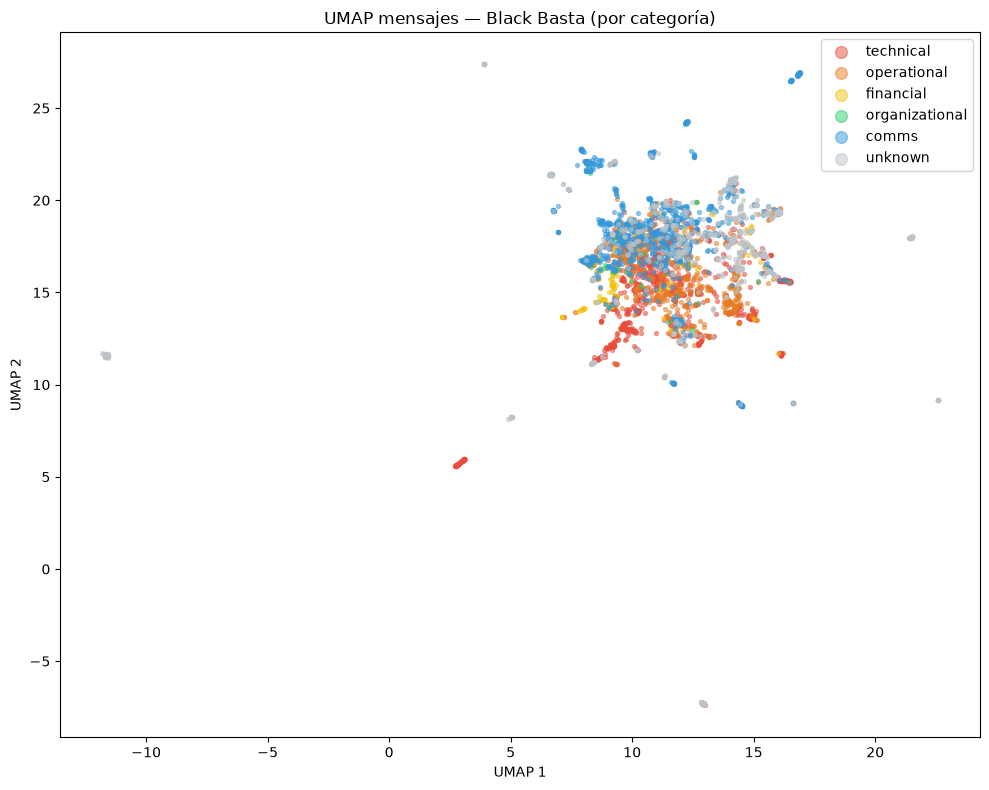

In [7]:
# Definimos un color específico para cada categoría de mensaje.
# Usamos colores contrastados para que las categorías sean fácilmente distinguibles
# en el gráfico de dispersión.
cat_color = {
    'technical':      '#e74c3c',   # rojo
    'operational':    '#e67e22',   # naranja
    'financial':      '#f1c40f',   # amarillo
    'organizational': '#2ecc71',   # verde
    'comms':          '#3498db',   # azul
    'unknown':        '#bdc3c7',   # gris
}

# Creamos la figura del gráfico de dispersión (scatter plot).
fig, ax = plt.subplots(figsize=(10, 8))

# Dibujamos cada categoría por separado para poder asignarles colores y etiquetas distintas.
for cat, color in cat_color.items():
    # Creamos una máscara booleana: True donde la categoría del mensaje coincide con 'cat'.
    mask = sample['category'] == cat

    # ax.scatter() dibuja los puntos del gráfico.
    # msg_2d[mask, 0] son las coordenadas X (UMAP 1) de los mensajes de esta categoría.
    # msg_2d[mask, 1] son las coordenadas Y (UMAP 2) de los mensajes de esta categoría.
    # s=8 es el tamaño de cada punto (pequeño porque hay miles de puntos).
    # alpha=0.5 hace los puntos semitransparentes para ver la densidad donde se superponen.
    # rasterized=True renderiza los miles de puntos como imagen bitmap para que el gráfico
    # no sea demasiado pesado.
    ax.scatter(msg_2d[mask, 0], msg_2d[mask, 1],
               c=color, s=8, alpha=0.5, label=cat, rasterized=True)

# Añadimos título, leyenda y etiquetas de ejes.
ax.set_title('UMAP mensajes — Black Basta (por categoría)')

# markerscale=3 hace los marcadores de la leyenda más grandes que los del gráfico
# para que sean más fáciles de ver.
ax.legend(markerscale=3)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

/tmp/ipykernel_26821/1834646706.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],


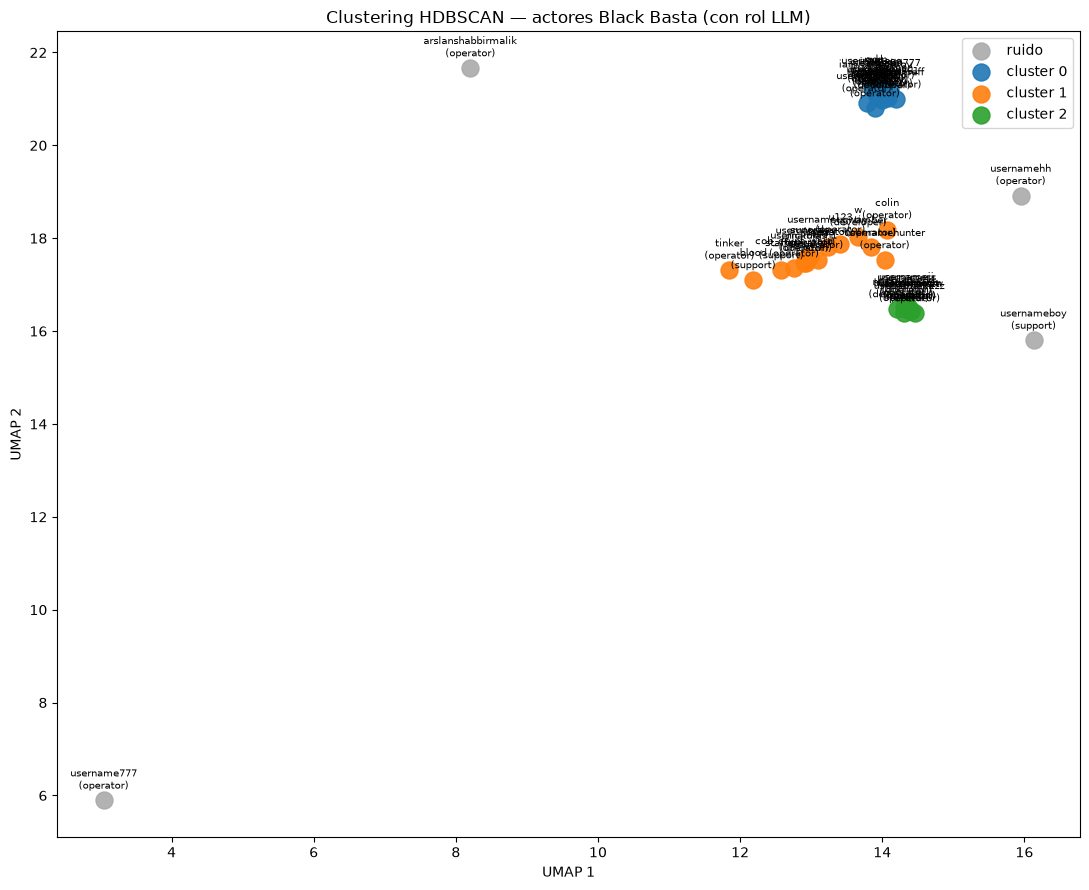

In [8]:
# Usamos la paleta de colores 'tab10' de matplotlib que tiene 10 colores distintos
# y bien diferenciados, ideal para representar clusters diferentes.
palette = cm.tab10.colors

# Creamos la figura del gráfico de actores coloreados por cluster.
fig, ax = plt.subplots(figsize=(11, 9))

# Dibujamos cada cluster por separado para asignarles colores y etiquetas distintas.
for cl in sorted(set(actor_clusters)):
    # Creamos una máscara booleana: True para los actores que pertenecen a este cluster.
    mask  = actor_clusters == cl

    # Los actores marcados como ruido (cl == -1) los pintamos de gris.
    # Los demás clusters reciben colores de la paleta tab10.
    # El operador % (módulo) hace que si hay más de 10 clusters, los colores se repitan.
    color = '#aaaaaa' if cl == -1 else palette[cl % len(palette)]
    label = 'ruido' if cl == -1 else f'cluster {cl}'

    # Dibujamos los puntos de los actores de este cluster.
    # s=150 hace los puntos grandes para que se vean bien las etiquetas encima.
    # alpha=0.9 los hace casi opacos.
    # zorder=3 hace que los puntos se dibujen por encima de cualquier otra capa del gráfico.
    ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],
               c=color, s=150, alpha=0.9, label=label, zorder=3)

# Añadimos etiquetas de texto junto a cada punto para identificar al actor y su rol.
for i, name in enumerate(actor_names):
    # Obtenemos el rol inferido por el LLM para este actor (o cadena vacía si no hay perfil).
    role = profiles.get(name, {}).get('role', '')

    # annotate() añade texto junto a un punto del gráfico.
    # El texto muestra el nombre del actor y su rol en la línea siguiente.
    # (actor_2d[i, 0], actor_2d[i, 1]) es la coordenada del punto (posición del texto).
    # fontsize=7 hace la letra pequeña para que quepan todos los nombres.
    # ha='center' centra el texto horizontalmente respecto al punto.
    # va='bottom' pone el texto justo encima del punto.
    # xytext=(0, 6) desplaza el texto 6 puntos hacia arriba para no taparlo.
    # textcoords='offset points' indica que el desplazamiento es en puntos de pantalla.
    ax.annotate(f'{name}\n({role})', (actor_2d[i, 0], actor_2d[i, 1]),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points')

ax.set_title('Clustering HDBSCAN — actores Black Basta (con rol LLM)')
ax.legend()
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

## 6. Similitud coseno entre actores

In [8]:
# Calculamos la similitud coseno entre todos los pares de actores.
# cosine_similarity(actor_matrix) devuelve una matriz cuadrada de (N_actores, N_actores)
# donde cada celda [i, j] contiene la similitud entre el actor i y el actor j.
# Un valor de 1.0 significa que los dos actores tienen patrones de comunicación idénticos.
# Un valor cercano a 0 significa que sus patrones son completamente distintos.
sim_matrix = cosine_similarity(actor_matrix)

# Ponemos la diagonal a -1 para que los actores no aparezcan como "más similares a sí mismos"
# al buscar los más parecidos. Cada actor tiene similitud 1.0 consigo mismo,
# y eso haría que siempre apareciera en el top-1 de su propio ranking.
np.fill_diagonal(sim_matrix, -1)

# Para cada actor, mostramos los 3 actores más similares a él.
print('=== TOP 3 MÁS SIMILARES POR ACTOR ===')
for i, actor in enumerate(actor_names):
    # np.argsort(sim_matrix[i]) ordena los índices de los actores de menor a mayor similitud.
    # [::-1] invierte el orden para tenerlos de mayor a menor.
    # [:3] se queda con los 3 primeros (los más similares).
    top3_idx = np.argsort(sim_matrix[i])[::-1][:3]

    # Construimos una lista de tuplas (nombre_actor, similitud) para los top 3.
    top3 = [(actor_names[j], sim_matrix[i, j]) for j in top3_idx]

    # Formateamos la salida para que sea legible: nombre (similitud con 3 decimales).
    pairs = ', '.join(f'{a} ({s:.3f})' for a, s in top3)

    # Obtenemos el rol del actor desde los perfiles para añadir contexto.
    role  = profiles.get(actor, {}).get('role', '?')
    print(f'  {actor:<20} [{role:<15}] → {pairs}')

=== TOP 3 MÁS SIMILARES POR ACTOR ===
  adm                  [operator       ] → chuck (0.989), u123 (0.985), lincoln (0.985)
  arslanshabbirmalik   [operator       ] → manager361 (0.919), manager880 (0.913), iamnurnazarov (0.899)
  blood                [support        ] → chuck (0.979), u123 (0.978), usernameugway (0.978)
  burito               [developer      ] → n3auxaxl (0.981), usernameff (0.978), usernamegg (0.978)
  cameron777           [operator       ] → usernamevv (0.976), usernamess (0.974), usernamegg (0.974)
  chuck                [operator       ] → adm (0.989), u123 (0.987), usernamegg (0.984)
  cob_crypt_ward       [operator       ] → usernameyy (0.980), usernamenn (0.979), staffer (0.979)
  colin                [operator       ] → iamnurnazarov (0.936), tinker (0.934), usernameugway (0.934)
  iamnurnazarov        [operator       ] → lincoln (0.979), mel (0.976), ugw (0.975)
  lapa                 [operator       ] → usernameugway (0.986), u123 (0.985), n3auxaxl (0.983)

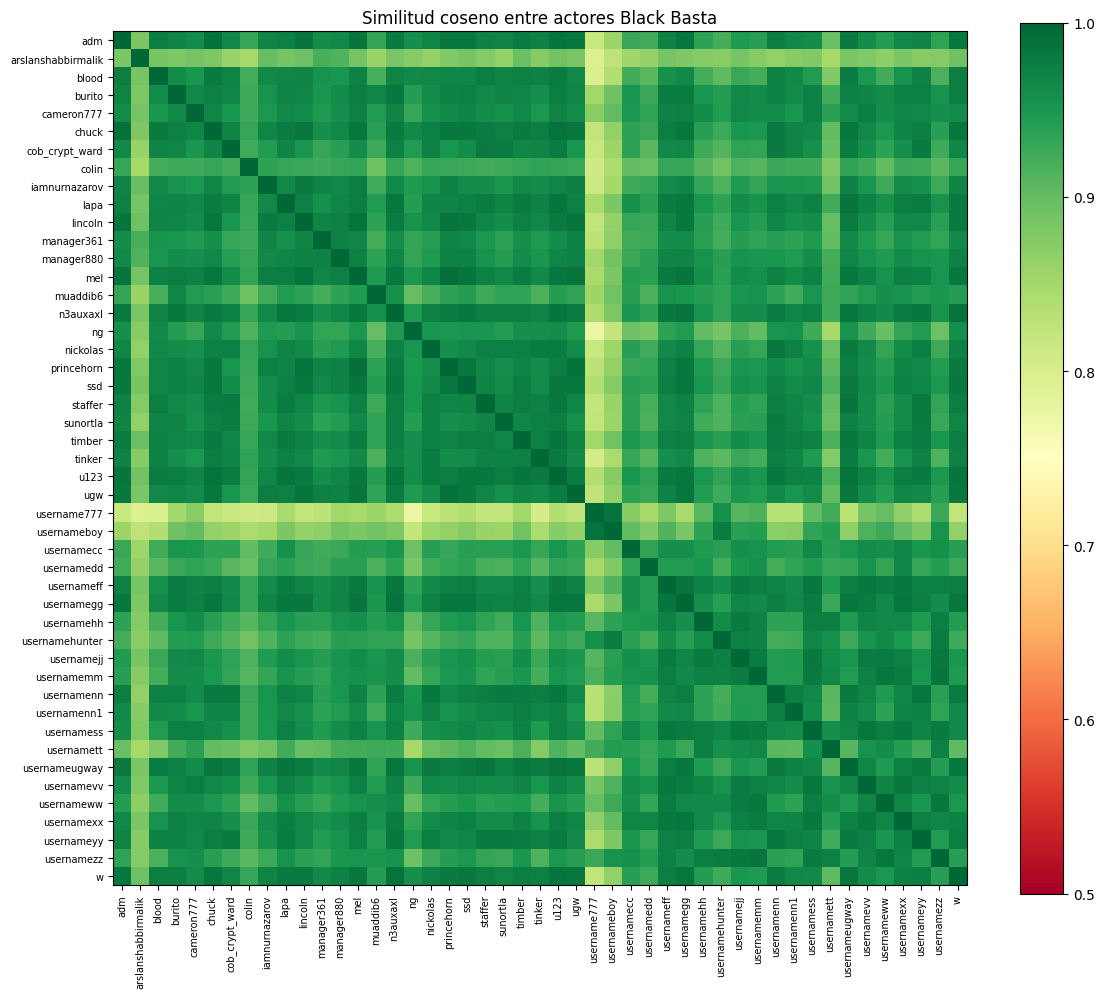

In [9]:
# Calculamos la similitud coseno de nuevo, esta vez sin poner la diagonal a -1,
# para que el heatmap muestre los valores reales (la diagonal siempre será 1.0).
sim_display = cosine_similarity(actor_matrix)

# Creamos la figura del heatmap.
# 12x10 pulgadas da espacio para mostrar los 47 nombres de actores en ambos ejes.
fig, ax = plt.subplots(figsize=(12, 10))

# imshow() dibuja la matriz de similitudes como un mapa de calor.
# cmap='RdYlGn': rojo (baja similitud, ~0.5) → amarillo → verde (alta similitud, 1.0).
# vmin=0.5, vmax=1.0: el rango de la escala de color. Empezamos en 0.5 porque
# todas las similitudes son bastante altas (los actores comparten el mismo contexto).
im = ax.imshow(sim_display, cmap='RdYlGn', vmin=0.5, vmax=1.0)

# Configuramos las etiquetas del eje X (actores en horizontal).
# rotation=90 gira los nombres 90 grados para que no se superpongan.
# fontsize=7 hace la letra pequeña para que quepan todos.
ax.set_xticks(range(len(actor_names)))
ax.set_xticklabels(actor_names, rotation=90, fontsize=7)

# Configuramos las etiquetas del eje Y (actores en vertical).
ax.set_yticks(range(len(actor_names)))
ax.set_yticklabels(actor_names, fontsize=7)

ax.set_title('Similitud coseno entre actores Black Basta')

# Añadimos la barra de color a la derecha que explica la escala visual.
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 7. Guardar

In [10]:
# Construimos el diccionario que mapea cada actor a su número de cluster.
# dict(zip(lista_a, lista_b)) crea un diccionario combinando dos listas elemento a elemento.
# Por ejemplo: {'adm': 0, 'burito': 0, 'arslanshabbirmalik': -1, ...}
actor_to_cluster = dict(zip(actor_names, actor_clusters))

# Añadimos el cluster, las coordenadas UMAP de cada mensaje a la muestra de salida.
sample_out = sample.copy()

# map() aplica el diccionario a cada valor de la columna 'username',
# reemplazando cada nombre de usuario por su número de cluster.
sample_out['cluster'] = sample_out['username'].map(actor_to_cluster)

# Añadimos las coordenadas UMAP de cada mensaje.
# msg_2d[:, 0] son todas las coordenadas X (primera columna de la matriz 2D).
# msg_2d[:, 1] son todas las coordenadas Y (segunda columna).
sample_out['umap_x']  = msg_2d[:, 0]
sample_out['umap_y']  = msg_2d[:, 1]

# Guardamos la muestra enriquecida en disco para usos futuros.
sample_out.to_parquet(SAMPLE_OUT, index=False)

# Construimos un DataFrame con los datos de cada actor a nivel de resumen:
# su cluster, sus coordenadas en el espacio UMAP y el rol asignado por el LLM.
actor_df = pd.DataFrame({
    'actor':      actor_names,
    'cluster':    actor_clusters,
    # Las coordenadas UMAP del centroide de cada actor.
    'umap_x':     actor_2d[:, 0],
    'umap_y':     actor_2d[:, 1],
    # El rol inferido por el LLM para cada actor (o 'unknown' si no hay perfil).
    'llm_role':   [profiles.get(a, {}).get('role', 'unknown') for a in actor_names],
    # El nivel de confianza del LLM en su inferencia del rol.
    'llm_conf':   [profiles.get(a, {}).get('confidence', 'low') for a in actor_names],
})

# Guardamos también el DataFrame de actores en disco.
actor_df.to_parquet(ACTOR_EMB_OUT, index=False)

# Confirmamos que todo se guardó correctamente con un resumen final.
print(f'Muestra con embeddings → {SAMPLE_OUT}')
print(f'Actor embeddings       → {ACTOR_EMB_OUT}')
print(f'Embeddings brutos      → {EMBEDDINGS_NPY}')
print(f'\nResumen: {len(embeddings):,} embeddings | {n_clusters} clusters | {n_noise} en ruido')

Muestra con embeddings → data/processed/bb_sample_with_embeddings.parquet
Actor embeddings       → data/processed/bb_actor_embeddings.parquet
Embeddings brutos      → data/processed/bb_message_embeddings.npy

Resumen: 3,598 embeddings | 3 clusters | 4 en ruido
